In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

In [3]:
import seaborn as sns

## Assumptions

1. Feedback is gathered during rather than after (we still have negative feedback for 0 risk customers)
2. Latest date is the max joining date

In [4]:
churn_df = pd.read_csv("./data/cleaned_churn_data.csv", index_col=0, parse_dates=["joining_date"])

In [5]:
# numerical features
numerical_features = ["avg_transaction_value", "points_in_wallet", "avg_time_spent", "tenure_days", "days_since_last_login", "age", "avg_frequency_login_days"]

# Categorical features
categorical_features = ['complaint_status', 'feedback', 'gender', 'internet_option', 
    'joined_through_referral', 'medium_of_operation',
    'offer_application_preference', 'past_complaint', 'preferred_offer_types', 
    'region_category', 'used_special_discount']

ordinal_features = ["membership_category"]

In [6]:
membership_order = ['No Membership', 'Basic Membership', 'Silver Membership', 
                    'Gold Membership', 'Premium Membership', 'Platinum Membership']

# Define the Log Transform function
log_transformer = FunctionTransformer(np.log1p, validate=True)

# Setup the preprocessor
# We'll log-transform on the big spender column, 
# and use RobustScaler on points to handle outliers without squishing.
preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_transformer, ['avg_transaction_value']),
        ('robust', RobustScaler(), ['points_in_wallet', 'avg_time_spent', 'tenure_days']),
        ('std', StandardScaler(), ['days_since_last_login', 'age', 'avg_frequency_login_days']),
        ('ord', OrdinalEncoder(categories=[membership_order]), ordinal_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

## Model Training

### Note on Class balance
From before, we saw that membership and feedback were one of the main things that differentiated the risk 0 with risk 1, so we want to ensure that we use K fold cross validation to get a model that works across many different splits of data and we can achieve that using K fold cross validation.

In [7]:
# Define the model pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5))
])

# Split data
X = churn_df.drop(["security_no", "referral_id", "churn_risk_score", "joining_date", "last_visit_time", "total_economic_value"], axis=1)
y = churn_df['churn_risk_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

# 1. Define the Parameter Grid
# Note: Since we are using a Pipeline, you must prefix the parameter name 
# with the name of the step in the pipeline (e.g., 'classifier__')
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0]
}

# 2. Setup Grid Search
# We focus on 'f1' or 'recall' because accurate churn prediction 
# is more important than overall accuracy.
grid_search = GridSearchCV(
    estimator=clf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1', # Use F1 score rather than accuracy
    n_jobs=-1, # Uses all CPU cores to speed it up
    verbose=2
)

# 3. Execute the Search
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=1.0; total time=   3.3s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=1.0; total time=   3.3s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8; total time=   3.9s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=1.0; total time=   3.6s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8; total time=   3.7s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__subsample=0.8; total time=   4.1s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estima

In [ ]:
results_df = pd.DataFrame(grid_search.cv_results_)

# Sort by rank and look at the top 5
results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head()

,params,mean_test_score,std_test_score,rank_test_score
8,"{'classifier__learning_rate': 0.01, 'classifie...",0.940392,0.002284,1
10,"{'classifier__learning_rate': 0.01, 'classifie...",0.940386,0.002158,2
6,"{'classifier__learning_rate': 0.01, 'classifie...",0.940342,0.002256,3
17,"{'classifier__learning_rate': 0.1, 'classifier...",0.940323,0.002008,4
11,"{'classifier__learning_rate': 0.01, 'classifie...",0.940210,0.002569,5


`std_test_score` is very low indicating that the model was stable and a high `mean_test_score` of 0.94 is a good sign that the model has a high precision and recall.

--- Model Performance Report ---
Accuracy: 0.9373

Classification Report:
               precision    recall  f1-score   support

 Low Risk (0)       0.92      0.95      0.93      3377
High Risk (1)       0.96      0.93      0.94      4022

     accuracy                           0.94      7399
    macro avg       0.94      0.94      0.94      7399
 weighted avg       0.94      0.94      0.94      7399



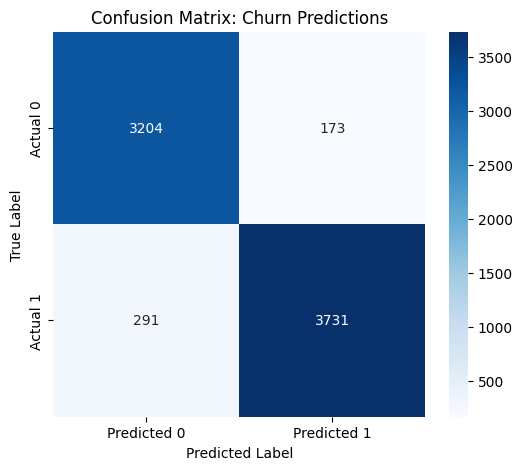

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Use the best model found by the grid search
best_clf = grid_search.best_estimator_

# 2. Predict on the totally unseen test set
y_eval_pred = best_clf.predict(X_test)

# 3. Print the overall performance
print("--- Model Performance Report ---")
print(f"Accuracy: {accuracy_score(y_test, y_eval_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_eval_pred, target_names=['Low Risk (0)', 'High Risk (1)']))

# 4. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_eval_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: Churn Predictions')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Feature Importance

In [16]:
one_hot_encoding_cols = best_clf.named_steps['preprocessor'].transformers_[4][1].get_feature_names_out()
all_features = numerical_features + ordinal_features + list(one_hot_encoding_cols) + ["points_per_dollar"]

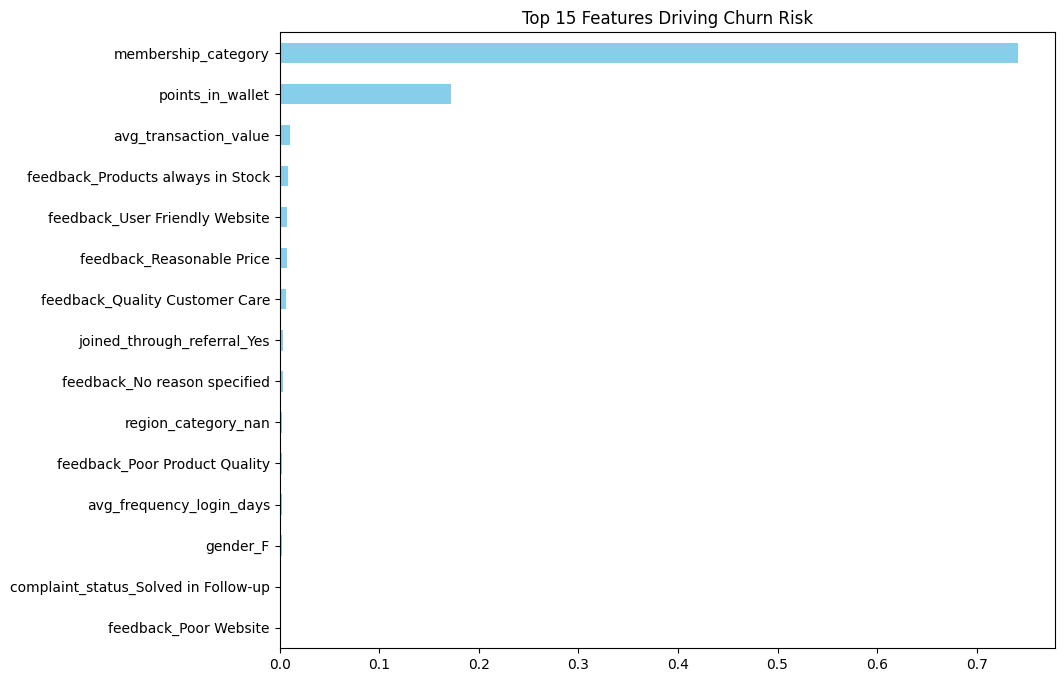

In [17]:
# 4. Check for 'Feature Dominance' one last time
importances = best_clf.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Features Driving Churn Risk')
plt.gca().invert_yaxis()
plt.show()

It is clear how `membership_category` and `points_in_wallet` strongly impact the classification. This lines up with what we saw during the EDA stage.

Interestingly, *positive feedback* such as `feedback_Products always in Stock`, `feedback_User Friendly Website` etc. is also one of the top-5 predictors that contributes to the churn risk classification. This may be something that **assists** the model to make the classification rather than be the **primary** feature that contributes to the classification. 

## SHAP Analysis 

In [19]:
import shap

# 1. Extract the preprocessor and the model from your best pipeline
preprocessor = best_clf.named_steps['preprocessor']
model = best_clf.named_steps['classifier']

# 3. Transform the test data
X_test_transformed = preprocessor.transform(X_test)

# 4. Initialize the SHAP Explainer
# TreeExplainer is optimized for XGBoost/Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

/home/aviraljain/Documents/kaggle/customer-churn-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


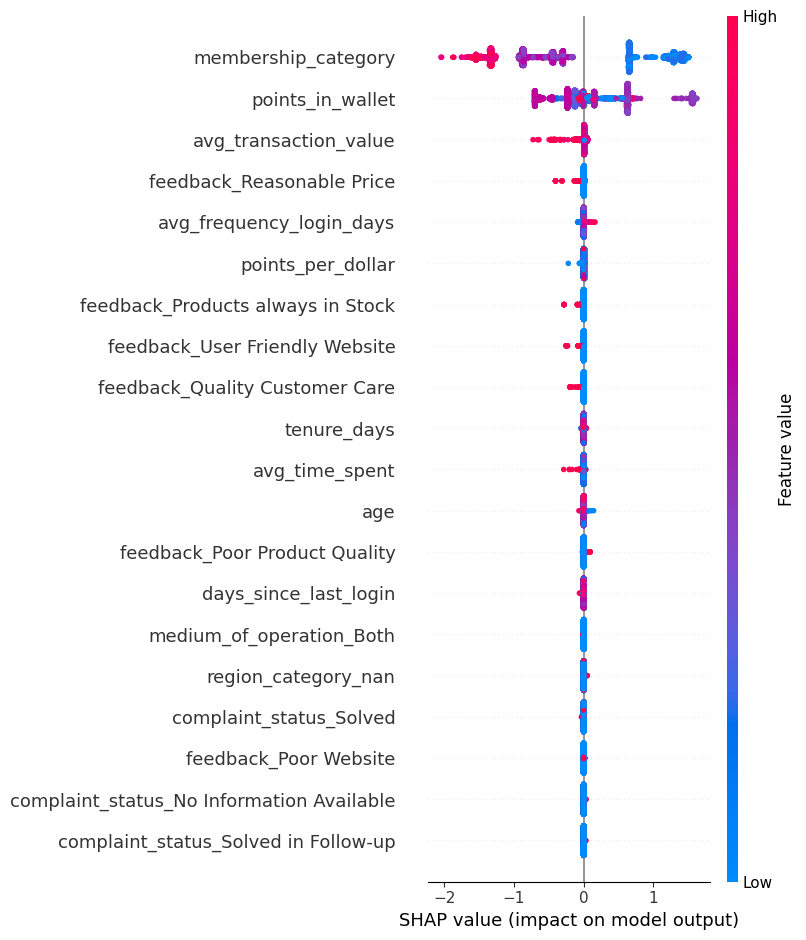

In [20]:
# Create the summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_features)

From the SHAP diagram, we can see that features such as `membership_category`, `points_in_wallet` and `avg_transaction_value` are quite strong indicators of churn. 

It is also good to see that positive feedback such as `feedback_Reasonable Price`, `feedback_Products always in Stock` etc. contribute to reducing risk of churn but they are not large contributors to churn risk.

Similarly, note that low values of `points_per_dollar` contributed to a lower churn, whereas higher values of `avg_frequency_login_days` contributed to a higher churn. All of these match our expectations.